# Maximum Likelihood Estimation (MLE): Complete Guide

## 1. Introduction to MLE
Maximum Likelihood Estimation (MLE) is a fundamental optimization framework used to estimate the parameters of a statistical model. It operates by selecting the parameter values that maximize the likelihood function, thereby making the observed data most probable under the assumed distribution.

Unlike Bayesian inference, which treats parameters as random variables with prior distributions, MLE treats parameters as fixed but unknown constants. The Likelihood is not a probability distribution over parameters; it is a measure of the plausibility of the parameters given the fixed, observed data.

In [1]:
# Setup and Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
import warnings

# Configure visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

# Set random seed for complete reproducibility
np.random.seed(42)

print("Environment initialized successfully.")

Environment initialized successfully.


## 2. Core Concept 1: Probability vs. Likelihood (Intuition)

The distinction between probability and likelihood is the most critical conceptual hurdle in MLE.

- Probability projects forward: Given a fixed parameter (e.g., a fair coin, p = 0.5), what is the probability of observing a specific sequence of data (e.g., 8 heads in 10 flips)?
- Likelihood projects backward: Given a fixed, observed sequence of data (e.g., 8 heads in 10 flips), how plausible are different parameter values (e.g., p = 0.5 vs p = 0.8)?

The Archer Analogy: You walk into an archery range and observe a target with three arrows clustered tightly in the top-right corner. Probability asks: If the archer aimed at the center, what is the chance they hit the top-right? (Very low). Likelihood asks: Given the arrows are in the top-right, where were they aiming? (The top right). MLE identifies the aim that makes the data most plausible.

In [2]:
# Data Creation: Generating a synthetic coin flip dataset (Bernoulli trials)
n_flips = 10
true_prob = 0.8

# 1 for Heads, 0 for Tails
observed_flips = np.random.binomial(n=1, p=true_prob, size=n_flips)
heads_count = np.sum(observed_flips)
tails_count = n_flips - heads_count

print(f"Observed Data Array: {observed_flips}")
print(f"Total Flips (n): {n_flips}")
print(f"Heads Observed (k): {heads_count}")

# Let's evaluate competing hypotheses
hypotheses = [0.2, 0.5, 0.8]
for p in hypotheses:
    likelihood = (p**heads_count) * ((1-p)**tails_count)
    print(f"Hypothesis p={p} -> Likelihood of this exact data: {likelihood:.6f}")

print("\nNotice how p=0.8 yields the highest likelihood for our specific observation.")

Observed Data Array: [1 0 1 1 1 1 1 0 1 1]
Total Flips (n): 10
Heads Observed (k): 8
Hypothesis p=0.2 -> Likelihood of this exact data: 0.000002
Hypothesis p=0.5 -> Likelihood of this exact data: 0.000977
Hypothesis p=0.8 -> Likelihood of this exact data: 0.006711

Notice how p=0.8 yields the highest likelihood for our specific observation.


## 3. Mathematical Formulation

Let X = (x1, x2, ..., xn) be a sequence of independent and identically distributed (i.i.d.) observations drawn from a population defined by a probability density function f(x | theta), where theta is the parameter vector.

Because observations are independent, the joint probability is the product of individual probabilities:
P(X | theta) = Product( f(xi | theta) ) for i=1 to n.

When viewed as a function of theta for a fixed dataset X, this is the Likelihood Function:
L(theta | X) = Product( f(xi | theta) )

The Log-Likelihood Function transforms products to sums, preventing numerical underflow:
ell(theta | X) = ln L(theta | X) = Sum( ln f(xi | theta) )

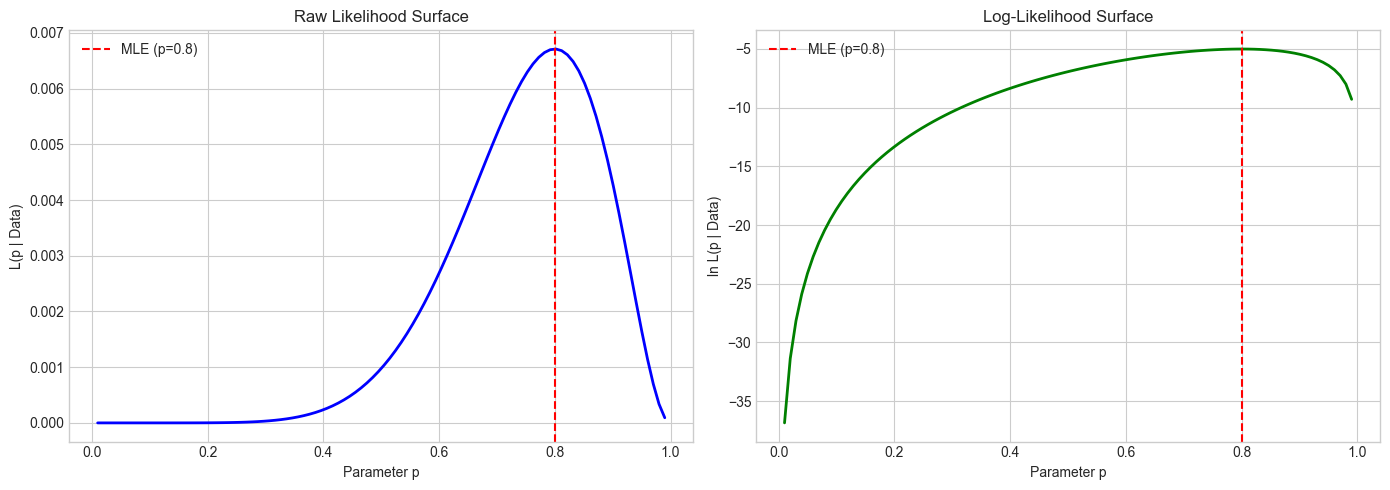

In [3]:
# Visualizing the Likelihood and Log-Likelihood surfaces
p_space = np.linspace(0.01, 0.99, 100)

# Compute raw likelihood
raw_likelihoods = (p_space**heads_count) * ((1-p_space)**tails_count)

# Compute log-likelihood
log_likelihoods = heads_count * np.log(p_space) + tails_count * np.log(1 - p_space)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(p_space, raw_likelihoods, color='blue', lw=2)
ax1.axvline(0.8, color='red', linestyle='--', label='MLE (p=0.8)')
ax1.set_title('Raw Likelihood Surface')
ax1.set_xlabel('Parameter p')
ax1.set_ylabel('L(p | Data)')
ax1.legend()

ax2.plot(p_space, log_likelihoods, color='green', lw=2)
ax2.axvline(0.8, color='red', linestyle='--', label='MLE (p=0.8)')
ax2.set_title('Log-Likelihood Surface')
ax2.set_xlabel('Parameter p')
ax2.set_ylabel('ln L(p | Data)')
ax2.legend()

plt.tight_layout()
plt.show()

## 4. The Score Function and Fisher Information

The first derivative of the log-likelihood function with respect to theta is called the Score function, S(theta). Finding the MLE requires finding the roots of the Score function.

S(theta) = d/d_theta ell(theta | X) = 0

The expected value of the squared Score (or the negative expected value of the second derivative) is the Fisher Information. It quantifies how much information the data provides about the parameter.

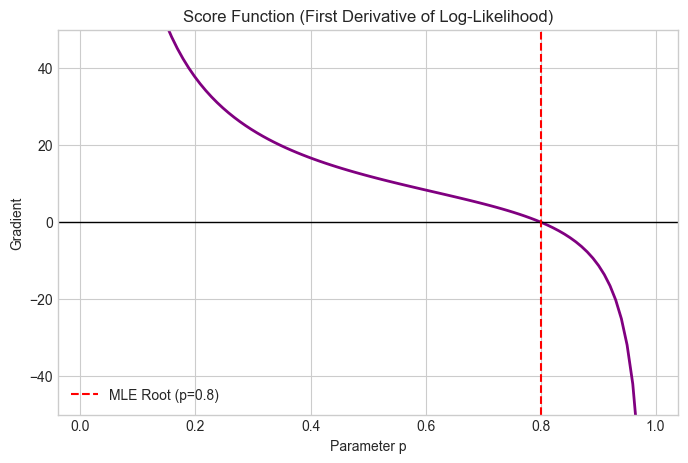

In [4]:
# Visualizing the Score Function for our coin flip example
# For binomial, d/dp (k*ln(p) + (n-k)*ln(1-p)) = k/p - (n-k)/(1-p)

score_values = (heads_count / p_space) - (tails_count / (1 - p_space))

plt.figure(figsize=(8, 5))
plt.plot(p_space, score_values, color='purple', lw=2)
plt.axhline(0, color='black', lw=1, linestyle='-')
plt.axvline(0.8, color='red', linestyle='--', label='MLE Root (p=0.8)')
plt.title('Score Function (First Derivative of Log-Likelihood)')
plt.xlabel('Parameter p')
plt.ylabel('Gradient')
plt.ylim(-50, 50)
plt.legend()
plt.show()

## 5. Core Concept 2: Gaussian Distribution MLE

For a Gaussian distribution N(mu, sigma^2), we want to estimate the mean (mu) and variance (sigma^2). Let's generate a continuous synthetic dataset to demonstrate this.

Generated 1000 Gaussian samples.
Data preview: [4.06 6.09 4.07 4.07 5.48]


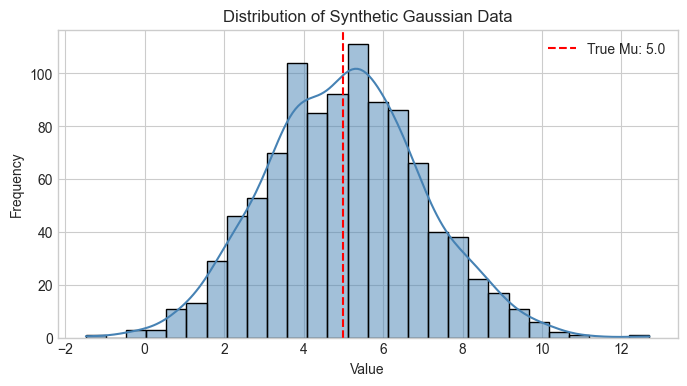

In [5]:
# Data Creation: Generating continuous Gaussian data
true_mu = 5.0
true_sigma = 2.0
n_samples = 1000

observed_gaussian_data = np.random.normal(loc=true_mu, scale=true_sigma, size=n_samples)

print(f"Generated {n_samples} Gaussian samples.")
print("Data preview:", np.round(observed_gaussian_data[:5], 2))

# Quick visualization of the distribution
plt.figure(figsize=(8, 4))
sns.histplot(observed_gaussian_data, kde=True, color="steelblue")
plt.axvline(true_mu, color="red", linestyle="--", label=f"True Mu: {true_mu}")
plt.title("Distribution of Synthetic Gaussian Data")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## 6. Analytical Derivation for Gaussian MLE

By taking the log-likelihood of the Gaussian PDF, differentiating with respect to mu and setting to zero, we get the analytical solution for mu:
$$mu_hat = Sum(xi) / n  (The sample mean)$$

Differentiating with respect to sigma^2 yields:
$$sigma2_hat = Sum((xi - mu_hat)^2) / n  (The biased sample variance)$$

Let's compute these analytically.

In [6]:
# Analytical MLE calculation
mu_mle_analytical = np.mean(observed_gaussian_data)

# Note: np.var with ddof=0 computes the biased population variance (MLE formulation)
# np.var with ddof=1 computes the unbiased sample variance
sigma2_mle_analytical = np.var(observed_gaussian_data, ddof=0)
sigma_mle_analytical = np.sqrt(sigma2_mle_analytical)

print("--- Analytical MLE Results ---")
print(f"Estimated Mu:    {mu_mle_analytical:.4f} (True: {true_mu})")
print(f"Estimated Sigma: {sigma_mle_analytical:.4f} (True: {true_sigma})")

--- Analytical MLE Results ---
Estimated Mu:    5.0386 (True: 5.0)
Estimated Sigma: 1.9563 (True: 2.0)


## 7. Numerical Optimization for Complex Models

In complex models (like neural networks or mixed-effects models), analytical solutions do not exist. We must use numerical optimization algorithms (like gradient descent or L-BFGS) to find the minimum of the Negative Log-Likelihood (NLL). Minimizing the NLL is mathematically identical to maximizing the Likelihood.

In [7]:
def negative_log_likelihood(params, data):
    """
    Calculates the Negative Log-Likelihood (NLL) for a Gaussian distribution.
    params = [mu, sigma]
    """
    mu, sigma = params
    
    # Enforce strict parameter bounds (sigma must be > 0)
    if sigma <= 0:
        return np.inf
        
    # Use scipy's norm.logpdf for numerical stability
    log_likelihood = np.sum(stats.norm.logpdf(data, loc=mu, scale=sigma))
    
    return -log_likelihood

# Initial guess [mu, sigma]
initial_guess = [0.0, 1.0]

# Optimization bounds: Mu is unconstrained, Sigma must be positive
bounds = [(None, None), (1e-5, None)]

print("Starting numerical optimization using L-BFGS-B...")
result = minimize(
    negative_log_likelihood, 
    initial_guess, 
    args=(observed_gaussian_data,), 
    method='L-BFGS-B', 
    bounds=bounds
)

mu_mle_numerical, sigma_mle_numerical = result.x

print(f"Optimization Success: {result.success}")
print(f"Optimization Message: {result.message}")
print("\n--- Numerical MLE Results ---")
print(f"Estimated Mu:    {mu_mle_numerical:.4f}")
print(f"Estimated Sigma: {sigma_mle_numerical:.4f}")

Starting numerical optimization using L-BFGS-B...
Optimization Success: True
Optimization Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

--- Numerical MLE Results ---
Estimated Mu:    5.0386
Estimated Sigma: 1.9563


## 8. Core Concept 3: Asymptotic Consistency

One of the most important properties of MLE is 'Consistency'. As the sample size n approaches infinity, the parameter estimates are guaranteed to converge to the true underlying population parameters.

We can demonstrate this by simulating MLE across increasing sample sizes.

In [8]:
# Simulating MLE Consistency
sample_sizes = [10, 50, 100, 500, 2000]
n_trials = 100

mu_simulations = {size: [] for size in sample_sizes}

print("Running Monte Carlo simulation for Consistency...")
for size in sample_sizes:
    for _ in range(n_trials):
        # Draw data
        sim_data = np.random.normal(loc=true_mu, scale=true_sigma, size=size)
        # Analytically calculate MLE for speed
        sim_mu = np.mean(sim_data)
        mu_simulations[size].append(sim_mu)

print("Simulation complete.")

Running Monte Carlo simulation for Consistency...
Simulation complete.


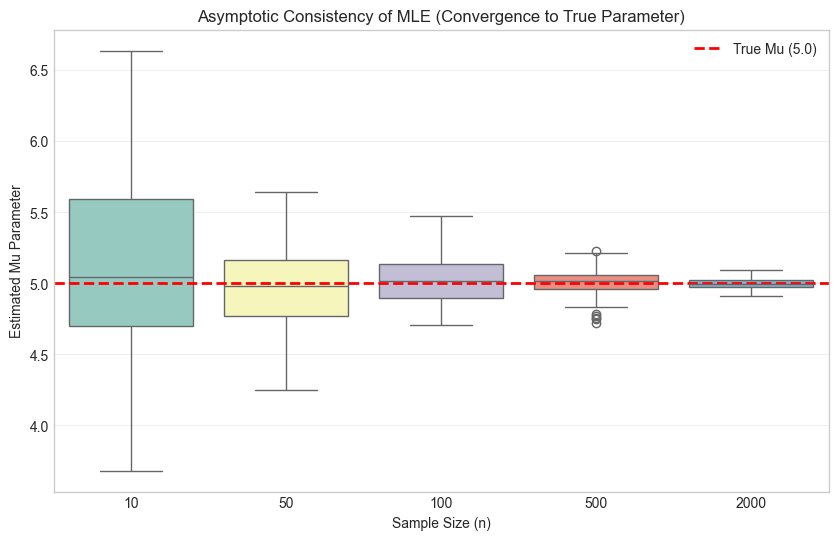

Notice how the variance of our estimates shrinks dramatically as N increases.


In [9]:
# Visualizing the convergence
plt.figure(figsize=(10, 6))
boxplot_data = [mu_simulations[size] for size in sample_sizes]

sns.boxplot(data=boxplot_data, palette="Set3")
plt.axhline(true_mu, color="red", linestyle="--", linewidth=2, label=f"True Mu ({true_mu})")

plt.xticks(ticks=range(len(sample_sizes)), labels=sample_sizes)
plt.title("Asymptotic Consistency of MLE (Convergence to True Parameter)")
plt.xlabel("Sample Size (n)")
plt.ylabel("Estimated Mu Parameter")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Notice how the variance of our estimates shrinks dramatically as N increases.")

## 9. Machine Learning Connection: MSE and MLE

MLE is the theoretical bedrock of supervised learning. If you assume the target variable 'y' is generated by a deterministic function plus Gaussian noise, maximizing the likelihood of the data is mathematically identical to minimizing the Mean Squared Error (MSE).

Let's demonstrate this equivalence with a simple Linear Regression.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Synthetic linear data with Gaussian noise
X_reg = np.random.uniform(0, 10, 100)
true_slope = 3.5
true_intercept = 10.0
noise = np.random.normal(0, 2.0, 100)
y_reg = true_slope * X_reg + true_intercept + noise

# 1. Scikit-Learn (Minimizing Mean Squared Error directly)
model = LinearRegression()
model.fit(X_reg.reshape(-1, 1), y_reg)
mse_slope = model.coef_[0]
mse_intercept = model.intercept_

# 2. Custom MLE (Minimizing Negative Log-Likelihood)
def linear_regression_nll(params):
    slope, intercept, sigma = params
    if sigma <= 0: return np.inf
    preds = slope * X_reg + intercept
    return -np.sum(stats.norm.logpdf(y_reg, loc=preds, scale=sigma))

res_reg = minimize(linear_regression_nll, [0, 0, 1], method='L-BFGS-B', 
                   bounds=[(None, None), (None, None), (1e-5, None)])
mle_slope, mle_intercept, _ = res_reg.x

print("--- Comparing MSE and MLE Optimization ---")
print(f"MSE OLS Solution : Slope = {mse_slope:.4f}, Intercept = {mse_intercept:.4f}")
print(f"MLE NLL Solution : Slope = {mle_slope:.4f}, Intercept = {mle_intercept:.4f}")
print("\nThe parameters are identical. Minimizing MSE is maximizing Gaussian Likelihood.")

--- Comparing MSE and MLE Optimization ---
MSE OLS Solution : Slope = 3.5089, Intercept = 9.9330
MLE NLL Solution : Slope = 3.5089, Intercept = 9.9330

The parameters are identical. Minimizing MSE is maximizing Gaussian Likelihood.


## 10. Common Pitfalls: Numerical Underflow & The Log-Sum-Exp Trick

When dealing with sums of exponentials (like Softmax or Gaussian Mixtures), direct computation overflows or underflows 64-bit floats. We must use the Log-Sum-Exp trick:
ln(Sum(exp(x))) = c + ln(Sum(exp(x - c))), where c = max(x)

This ensures numerical stability while preserving mathematical equality.

In [11]:
# Demonstration of the Log-Sum-Exp Trick
huge_values = np.array([1000.0, 1010.0, 1020.0])

print("Array of values:", huge_values)

# Naive computation (will result in overflow / inf)
with np.errstate(over='ignore'):
    naive_result = np.log(np.sum(np.exp(huge_values)))
    print(f"\nNaive computation result: {naive_result} (Overflowed!)")

# Log-Sum-Exp formulation
c = np.max(huge_values)
stable_result = c + np.log(np.sum(np.exp(huge_values - c)))

print(f"Stable Log-Sum-Exp result: {stable_result:.4f}")
print("Numerical stability achieved without altering the underlying math.")

Array of values: [1000. 1010. 1020.]

Naive computation result: inf (Overflowed!)
Stable Log-Sum-Exp result: 1020.0000
Numerical stability achieved without altering the underlying math.


## 11. Edge Cases: Parameter Boundaries

Standard calculus assumes the optimal parameter lies inside the parameter space, allowing us to find it by setting the derivative to zero. For distributions where the boundary depends on the parameter (e.g., Uniform Distribution), the derivative is never zero.

For a Uniform(0, theta) distribution, the MLE is simply the maximum observed value.

True Uniform Bound: 42.0
Maximum Observed Value (MLE): 40.4563


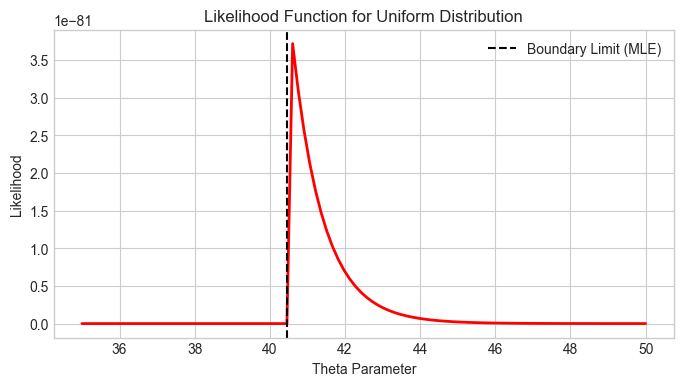

In [12]:
true_uniform_bound = 42.0
uniform_data = np.random.uniform(0, true_uniform_bound, 50)

# Analytical MLE for Uniform is the maximum element
mle_uniform = np.max(uniform_data)

print(f"True Uniform Bound: {true_uniform_bound}")
print(f"Maximum Observed Value (MLE): {mle_uniform:.4f}")

x_vals = np.linspace(35, 50, 100)
likelihoods = [ (1/x)**50 if x >= mle_uniform else 0 for x in x_vals ]

plt.figure(figsize=(8, 4))
plt.plot(x_vals, likelihoods, color="red", lw=2)
plt.axvline(mle_uniform, color="black", linestyle="--", label="Boundary Limit (MLE)")
plt.title("Likelihood Function for Uniform Distribution")
plt.xlabel("Theta Parameter")
plt.ylabel("Likelihood")
plt.legend()
plt.show()

## 12. Practice Exercise: Poisson Distribution MLE

The Poisson distribution models count data (e.g., call center arrivals). It is defined by a single rate parameter, lambda.

Task: Given the synthetic dataset below, find the MLE for lambda numerically using Scipy, and verify it against the known analytical solution (the sample mean).

In [13]:
# Data Generation for Exercise
true_lambda = 4.5
poisson_data = np.random.poisson(lam=true_lambda, size=200)

print("Generated 200 Poisson samples.")
print("First 10 samples:", poisson_data[:10])

Generated 200 Poisson samples.
First 10 samples: [3 8 4 7 6 8 4 4 6 5]


### Solution

In [14]:
def poisson_nll(params, data):
    lam = params[0]
    if lam <= 0:
        return np.inf
    return -np.sum(stats.poisson.logpmf(data, mu=lam))

# Numerical Solution
poisson_res = minimize(poisson_nll, [1.0], args=(poisson_data,), method='Nelder-Mead')
numerical_lam = poisson_res.x[0]

# Analytical Solution
analytical_lam = np.mean(poisson_data)

print(f"Numerical Solution via Optimization: {numerical_lam:.4f}")
print(f"Analytical Solution (Sample Mean): {analytical_lam:.4f}")
print("Exercise verified successfully.")

Numerical Solution via Optimization: 4.7700
Analytical Solution (Sample Mean): 4.7700
Exercise verified successfully.


## 13. Visualization Gallery: 3D Likelihood Landscape

To deeply understand what the optimization algorithm is doing, let's visualize the 2D parameter space (Mu and Sigma) for our Gaussian data as a 3D surface map. The optimizer behaves like a ball rolling to the lowest point of the Negative Log-Likelihood valley.

Computing 3D landscape... this may take a moment.


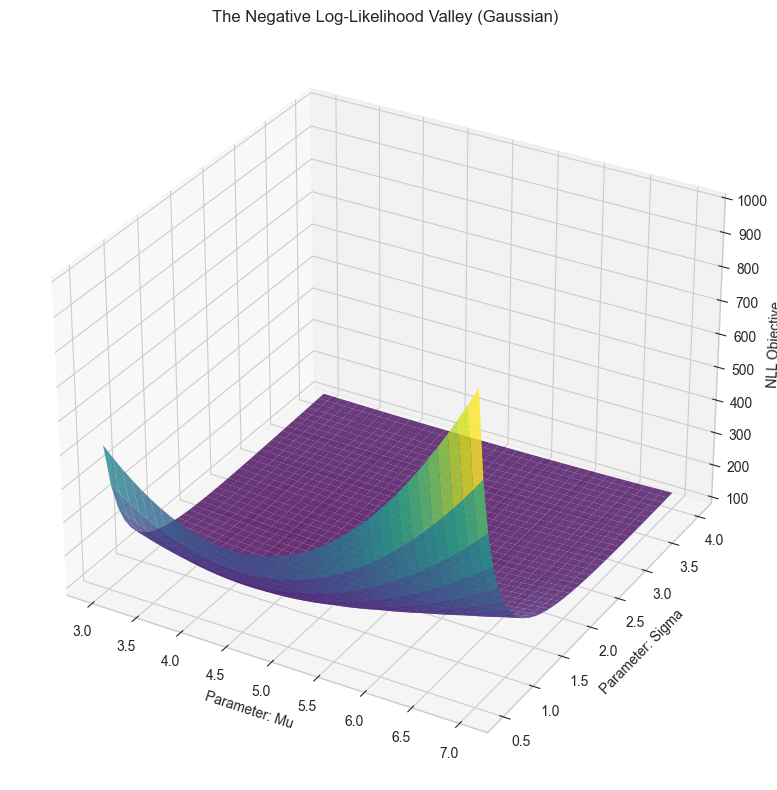

In [15]:
# Creating a grid of parameters around the true values
mu_grid = np.linspace(3, 7, 40)
sigma_grid = np.linspace(0.5, 4.0, 40)
MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)
Z = np.zeros_like(MU)

print("Computing 3D landscape... this may take a moment.")
# Use a smaller sample to make the valley wider and easier to see
subset_data = observed_gaussian_data[:50]

for i in range(MU.shape[0]):
    for j in range(MU.shape[1]):
        Z[i, j] = negative_log_likelihood([MU[i, j], SIGMA[i, j]], subset_data)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(MU, SIGMA, Z, cmap='viridis', alpha=0.8, edgecolor='none')
ax.set_title('The Negative Log-Likelihood Valley (Gaussian)')
ax.set_xlabel('Parameter: Mu')
ax.set_ylabel('Parameter: Sigma')
ax.set_zlabel('NLL Objective')

plt.tight_layout()
plt.show()

## 14. Summary and Key Takeaways

- **The Paradigm Shift**: MLE views data as fixed evidence and searches for the parameter hypothesis that makes the evidence least surprising.
- **Log Transformation**: Required to convert probability products into sums, preventing numerical underflow on computer architecture.
- **Asymptotic Properties**: With infinite data, MLE guarantees consistency (finding the truth) and efficiency (lowest possible variance).
- **ML Equivalence**: Minimizing standard regression/classification loss functions is mathematically identical to performing MLE under specific noise assumptions.